In [5]:
import pandas as pd
import tsfeatures as tsf
import matplotlib.pyplot as plt
import seaborn as sns
from utilsforecast.plotting import plot_series

<div dir="rtl" align="right">

**مدل‌های محک یا پایه (Benchmark methods):** روش‌های خیلی ساده‌ای (مثل این‌که بگیم مقدار فردا برابر است با مقدار امروز) که مثل خط‌کش عمل می‌کنند. هر مدل خفنی که بعداً بسازی، باید اول ثابت کنه از این روش‌های ساده بهتره!

**بررسی عملکرد مدل (Diagnostic checks):** آیا مدلی که ساختیم تمام الگوها و اطلاعات داده رو کشیده بیرون، یا هنوز نکاتی هست که مدل نتونسته یاد بگیره؟ (بررسی پسماندها یا Residuals).

**بازه اطمینان پیش‌بینی (Prediction intervals):** به جای این‌که فقط یک عدد قطعی بگیم (مثلاً «فردا فروش ۱۰۰ تاست»)، یک بازه مشخص کنیم («با احتمال ۹۵٪ بین ۹۰ تا ۱۱۰ تاست») تا عدم قطعیت آینده رو نشون بدیم.

**ارزیابی دقت (Evaluating accuracy):** استفاده از معیارهای استاندارد (مثل MAE یا RMSE) برای این‌که بفهمیم خطای کارمون چقدر بوده.


</div>

**Data preparation (tidy)**

The first step in forecasting is to prepare data in the correct format. This process may involve loading in data, identifying missing values, filtering the time series, and other pre-processing tasks. The functionality provided by pandas substantially simplifies this step.

Many models have different data requirements; some require the series to be in time order, others require no missing values. Checking your data is an essential step to understanding its features and should always be done before models are estimated.

In [3]:
gdp_df = (pd.read_csv("C:\\Users\\dell\\forecasting\\global_economy.csv", parse_dates=["ds"])[["unique_id", "ds", "GDP", "Population"]]
    .assign( GDP=lambda x: x["GDP"].interpolate(), Population=lambda x: x["Population"].interpolate(), y=lambda x: x["GDP"] / x["Population"])
)

**Plot the data (visualise)**

As we have seen in Chapter 2, visualisation is an essential step in understanding the data. Looking at your data allows you to identify common patterns, and subsequently specify an appropriate model.

In [4]:
gdp_df.head()

,unique_id,ds,GDP,Population,y
0,Afghanistan,1960-01-01,5.377778e+08,8996351.0,59.777327
1,Afghanistan,1961-01-01,5.488889e+08,9166764.0,59.878153
2,Afghanistan,1962-01-01,5.466667e+08,9345868.0,58.492874
3,Afghanistan,1963-01-01,7.511112e+08,9533954.0,78.782758
4,Afghanistan,1964-01-01,8.000000e+08,9731361.0,82.208444


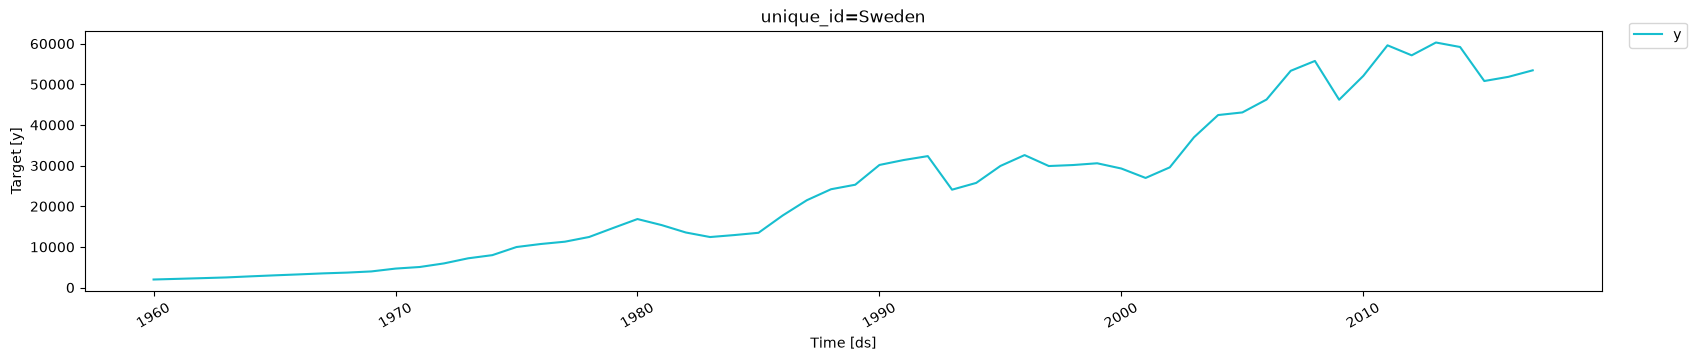

In [7]:
plot_series(gdp_df, ids=["Sweden"])

**Define a model (specify)**

Specifying an appropriate model for the data is essential for producing appropriate forecasts.


**Train the model (estimate)**

Once an appropriate model is specified, we next train the model on some data

In [8]:
sweden_df = gdp_df.loc[lambda x : x["unique_id"] == "Sweden"][["unique_id" , "ds" , "y"]]